In [5]:
import pandas as pd
import os
# Path to your CSV file
csv_path = r"D:\Sam\Carbon Stock\Remodelling Allometric Biomass\Summaries\Summary_Stats.csv"

# Load the CSV into a DataFrame
df = pd.read_csv(csv_path)

# Display the contents
print(df)

      Layer                                               Path         Min  \
0  AGB 1990  D:\Sam\Carbon Stock\Remodelling Allometric Bio...  265.679260   
1  AGB 1995  D:\Sam\Carbon Stock\Remodelling Allometric Bio...  257.882294   
2  AGB 2000  D:\Sam\Carbon Stock\Remodelling Allometric Bio...    0.000000   
3  AGB 2005  D:\Sam\Carbon Stock\Remodelling Allometric Bio...    9.834850   
4  AGB 2010  D:\Sam\Carbon Stock\Remodelling Allometric Bio...  237.249863   
5  AGB 2015  D:\Sam\Carbon Stock\Remodelling Allometric Bio...  431.670136   
6  AGB 2020  D:\Sam\Carbon Stock\Remodelling Allometric Bio...  378.668854   
7  AGB 2024  D:\Sam\Carbon Stock\Remodelling Allometric Bio...  381.495087   

           Max         Mean      StdDev  
0  2174.965332   948.064928  256.913226  
1  1949.392212   945.875513  240.865699  
2  2517.571777   970.497862  272.020524  
3    51.271648    26.408977    6.566898  
4  2175.482666   958.248785  245.596057  
5  2665.772461   979.366989  234.768807  
6  

In [2]:
df.head()

,Layer,Path,Min,Max,Mean,StdDev
0,AGB 1990,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,265.679260,2174.965332,948.064928,256.913226
1,AGB 1995,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,257.882294,1949.392212,945.875513,240.865699
2,AGB 2000,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,0.000000,2517.571777,970.497862,272.020524
3,AGB 2005,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,9.834850,51.271648,26.408977,6.566898
4,AGB 2010,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,237.249863,2175.482666,958.248785,245.596057


In [3]:
# Display all values in the 'Path' column
path_values = df['Path']
print(path_values)

0    D:\Sam\Carbon Stock\Remodelling Allometric Bio...
1    D:\Sam\Carbon Stock\Remodelling Allometric Bio...
2    D:\Sam\Carbon Stock\Remodelling Allometric Bio...
3    D:\Sam\Carbon Stock\Remodelling Allometric Bio...
4    D:\Sam\Carbon Stock\Remodelling Allometric Bio...
5    D:\Sam\Carbon Stock\Remodelling Allometric Bio...
6    D:\Sam\Carbon Stock\Remodelling Allometric Bio...
7    D:\Sam\Carbon Stock\Remodelling Allometric Bio...
Name: Path, dtype: object


In [7]:
import rasterio
import numpy as np
import pandas as pd

# Initialize list to store results
results = []

for index, row in df.iterrows():
    file_path = row['Path']
    try:
        with rasterio.open(file_path) as src:
            data = src.read(1)  # Read first band
            
            # Replace zeros with NaN to ignore zeros in stats
            data_no_zero = np.where(data == 0, np.nan, data)
            
            # Calculate statistics
            min_val = np.nanmin(data_no_zero)
            max_val = np.nanmax(data_no_zero)
            mean_val = np.nanmean(data_no_zero)
            std_dev = np.nanstd(data_no_zero)
            
            results.append({
                'File': os.path.basename(file_path),
                'Path': file_path,
                'Min': min_val,
                'Max': max_val,
                'Mean': mean_val,
                'StdDev': std_dev
            })
    except Exception as e:
        print(f"Error processing {file_path}: {e}")

# Convert results into a DataFrame
stats_df = pd.DataFrame(results)
print(stats_df)

                                      File  \
0  AGB_Chave_Mg_ha_1990_UTM35N_clipped.tif   
1  AGB_Chave_Mg_ha_1995_UTM35N_clipped.tif   
2  AGB_Chave_Mg_ha_2000_UTM35N_clipped.tif   
3  AGB_Chave_Mg_ha_2005_UTM35N_clipped.tif   
4  AGB_Chave_Mg_ha_2010_UTM35N_clipped.tif   
5  AGB_Chave_Mg_ha_2015_UTM35N_clipped.tif   
6  AGB_Chave_Mg_ha_2020_UTM35N_clipped.tif   
7  AGB_Chave_Mg_ha_2024_UTM35N_clipped.tif   

                                                Path         Min          Max  \
0  D:\Sam\Carbon Stock\Remodelling Allometric Bio...  265.679260  2174.965332   
1  D:\Sam\Carbon Stock\Remodelling Allometric Bio...  257.882294  1949.392212   
2  D:\Sam\Carbon Stock\Remodelling Allometric Bio...  262.462677  2517.571777   
3  D:\Sam\Carbon Stock\Remodelling Allometric Bio...    9.834850    51.271648   
4  D:\Sam\Carbon Stock\Remodelling Allometric Bio...  237.249863  2175.482666   
5  D:\Sam\Carbon Stock\Remodelling Allometric Bio...  431.670135  2665.772461   
6  D:\Sam\Carbon S

In [9]:
stats_df.head(10)

,File,Path,Min,Max,Mean,StdDev
0,AGB_Chave_Mg_ha_1990_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,265.679260,2174.965332,948.064819,256.913086
1,AGB_Chave_Mg_ha_1995_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,257.882294,1949.392212,945.875549,240.865631
2,AGB_Chave_Mg_ha_2000_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,262.462677,2517.571777,971.273071,270.742706
3,AGB_Chave_Mg_ha_2005_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,9.834850,51.271648,26.408976,6.566746
4,AGB_Chave_Mg_ha_2010_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,237.249863,2175.482666,958.248901,245.595886
5,AGB_Chave_Mg_ha_2015_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,431.670135,2665.772461,979.366638,234.768646
6,AGB_Chave_Mg_ha_2020_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,378.668854,2661.814697,1040.418823,295.094971
7,AGB_Chave_Mg_ha_2024_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,381.495087,2658.056396,1017.812256,272.173004


In [10]:
import rasterio
import numpy as np
import pandas as pd
import os

# Initialize list to store results
results = []

for index, row in df.iterrows():
    file_path = row['Path']
    try:
        with rasterio.open(file_path) as src:
            data = src.read(1)  # Read first band
            
            # Replace zeros with NaN to exclude them
            data_no_zero = np.where(data == 0, np.nan, data)
            
            # Count valid pixels (non-NaN)
            pixel_count = np.count_nonzero(~np.isnan(data_no_zero))
            
            # Calculate statistics
            min_val = np.nanmin(data_no_zero)
            max_val = np.nanmax(data_no_zero)
            mean_val = np.nanmean(data_no_zero)
            std_dev = np.nanstd(data_no_zero)
            
            results.append({
                'File': os.path.basename(file_path),
                'Path': file_path,
                'PixelCount': pixel_count,
                'Min': min_val,
                'Max': max_val,
                'Mean': mean_val,
                'StdDev': std_dev
            })
    except Exception as e:
        print(f"Error processing {file_path}: {e}")

# Convert results into a DataFrame
stats_df = pd.DataFrame(results)
print(stats_df)

                                      File  \
0  AGB_Chave_Mg_ha_1990_UTM35N_clipped.tif   
1  AGB_Chave_Mg_ha_1995_UTM35N_clipped.tif   
2  AGB_Chave_Mg_ha_2000_UTM35N_clipped.tif   
3  AGB_Chave_Mg_ha_2005_UTM35N_clipped.tif   
4  AGB_Chave_Mg_ha_2010_UTM35N_clipped.tif   
5  AGB_Chave_Mg_ha_2015_UTM35N_clipped.tif   
6  AGB_Chave_Mg_ha_2020_UTM35N_clipped.tif   
7  AGB_Chave_Mg_ha_2024_UTM35N_clipped.tif   

                                                Path  PixelCount         Min  \
0  D:\Sam\Carbon Stock\Remodelling Allometric Bio...      775374  265.679260   
1  D:\Sam\Carbon Stock\Remodelling Allometric Bio...      775374  257.882294   
2  D:\Sam\Carbon Stock\Remodelling Allometric Bio...      775374  262.462677   
3  D:\Sam\Carbon Stock\Remodelling Allometric Bio...       21559    9.834850   
4  D:\Sam\Carbon Stock\Remodelling Allometric Bio...      775374  237.249863   
5  D:\Sam\Carbon Stock\Remodelling Allometric Bio...      775993  431.670135   
6  D:\Sam\Carbon Stock\Re

In [11]:
stats_df.head(10)

,File,Path,PixelCount,Min,Max,Mean,StdDev
0,AGB_Chave_Mg_ha_1990_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,775374,265.679260,2174.965332,948.064819,256.913086
1,AGB_Chave_Mg_ha_1995_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,775374,257.882294,1949.392212,945.875549,240.865631
2,AGB_Chave_Mg_ha_2000_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,775374,262.462677,2517.571777,971.273071,270.742706
3,AGB_Chave_Mg_ha_2005_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,21559,9.834850,51.271648,26.408976,6.566746
4,AGB_Chave_Mg_ha_2010_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,775374,237.249863,2175.482666,958.248901,245.595886
5,AGB_Chave_Mg_ha_2015_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,775993,431.670135,2665.772461,979.366638,234.768646
6,AGB_Chave_Mg_ha_2020_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,775993,378.668854,2661.814697,1040.418823,295.094971
7,AGB_Chave_Mg_ha_2024_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,775993,381.495087,2658.056396,1017.812256,272.173004


In [12]:
import re

# Function to extract year from filename
def extract_year(filename):
    match = re.search(r'(\d{4})', filename)
    return int(match.group(1)) if match else None

# Assuming stats_df already exists, add the 'Year' column
stats_df['Year'] = stats_df['File'].apply(extract_year)

stats_df.head(10)

,File,Path,PixelCount,Min,Max,Mean,StdDev,Year
0,AGB_Chave_Mg_ha_1990_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,775374,265.679260,2174.965332,948.064819,256.913086,1990
1,AGB_Chave_Mg_ha_1995_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,775374,257.882294,1949.392212,945.875549,240.865631,1995
2,AGB_Chave_Mg_ha_2000_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,775374,262.462677,2517.571777,971.273071,270.742706,2000
3,AGB_Chave_Mg_ha_2005_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,21559,9.834850,51.271648,26.408976,6.566746,2005
4,AGB_Chave_Mg_ha_2010_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,775374,237.249863,2175.482666,958.248901,245.595886,2010
5,AGB_Chave_Mg_ha_2015_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,775993,431.670135,2665.772461,979.366638,234.768646,2015
6,AGB_Chave_Mg_ha_2020_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,775993,378.668854,2661.814697,1040.418823,295.094971,2020
7,AGB_Chave_Mg_ha_2024_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,775993,381.495087,2658.056396,1017.812256,272.173004,2024


In [13]:
import numpy as np
import re

# Function to extract year from filename
def extract_year(filename):
    match = re.search(r'(\d{4})', filename)
    return int(match.group(1)) if match else None

# Assuming you have your existing stats_df, and all calculations are done
# Now, we need to recalculate or update the DataFrame to include median

# Recompute the median for each image
# Note: You need access to the data array for each file again
# If you have the data stored, here's an example approach:

# Initialize list for results with median
results_with_median = []

for index, row in df.iterrows():
    file_path = row['Path']
    try:
        with rasterio.open(file_path) as src:
            data = src.read(1)
            data_no_zero = np.where(data == 0, np.nan, data)
            median_val = np.nanmedian(data_no_zero)
            # Add other stats as needed
            pixel_count = np.count_nonzero(~np.isnan(data_no_zero))
            min_val = np.nanmin(data_no_zero)
            max_val = np.nanmax(data_no_zero)
            mean_val = np.nanmean(data_no_zero)
            std_dev = np.nanstd(data_no_zero)

            results_with_median.append({
                'File': os.path.basename(file_path),
                'Path': file_path,
                'PixelCount': pixel_count,
                'Min': min_val,
                'Max': max_val,
                'Mean': mean_val,
                'StdDev': std_dev,
                'Median': median_val
            })
    except Exception as e:
        print(f"Error processing {file_path}: {e}")

# Convert to DataFrame
stats_df = pd.DataFrame(results_with_median)

# Add 'Year' column
stats_df['Year'] = stats_df['File'].apply(extract_year)

stats_df.head(10)

,File,Path,PixelCount,Min,Max,Mean,StdDev,Median,Year
0,AGB_Chave_Mg_ha_1990_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,775374,265.679260,2174.965332,948.064819,256.913086,949.208984,1990
1,AGB_Chave_Mg_ha_1995_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,775374,257.882294,1949.392212,945.875549,240.865631,940.954590,1995
2,AGB_Chave_Mg_ha_2000_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,775374,262.462677,2517.571777,971.273071,270.742706,947.061218,2000
3,AGB_Chave_Mg_ha_2005_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,21559,9.834850,51.271648,26.408976,6.566746,26.355526,2005
4,AGB_Chave_Mg_ha_2010_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,775374,237.249863,2175.482666,958.248901,245.595886,950.274597,2010
5,AGB_Chave_Mg_ha_2015_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,775993,431.670135,2665.772461,979.366638,234.768646,951.990601,2015
6,AGB_Chave_Mg_ha_2020_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,775993,378.668854,2661.814697,1040.418823,295.094971,1044.828003,2020
7,AGB_Chave_Mg_ha_2024_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,775993,381.495087,2658.056396,1017.812256,272.173004,1005.123474,2024


In [14]:
import numpy as np
import pandas as pd
import os
import re
from scipy import stats
import rasterio

# Function to extract year from filename
def extract_year(filename):
    match = re.search(r'(\d{4})', filename)
    return int(match.group(1)) if match else None

# Initialize list for results with mode
results_with_mode = []

for index, row in df.iterrows():
    file_path = row['Path']
    try:
        with rasterio.open(file_path) as src:
            data = src.read(1)
            data_no_zero = np.where(data == 0, np.nan, data)
            # Compute mode, ignoring NaNs
            data_flat = data_no_zero[~np.isnan(data_no_zero)]
            mode_result = stats.mode(data_flat, nan_policy='omit')
            mode_value = mode_result.mode[0] if mode_result.count[0] > 0 else np.nan
            
            pixel_count = len(data_flat)
            min_val = np.nanmin(data_no_zero)
            max_val = np.nanmax(data_no_zero)
            mean_val = np.nanmean(data_no_zero)
            std_dev = np.nanstd(data_no_zero)
            median_val = np.nanmedian(data_no_zero)

            results_with_mode.append({
                'File': os.path.basename(file_path),
                'Path': file_path,
                'PixelCount': pixel_count,
                'Min': min_val,
                'Max': max_val,
                'Mean': mean_val,
                'StdDev': std_dev,
                'Median': median_val,
                'Mode': mode_value
            })
    except Exception as e:
        print(f"Error processing {file_path}: {e}")

# Convert to DataFrame
stats_df = pd.DataFrame(results_with_mode)

# Add 'Year' column
stats_df['Year'] = stats_df['File'].apply(extract_year)

stats_df.head(10)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_14496\2442507869.py:24: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode_result = stats.mode(data_flat, nan_policy='omit')


,File,Path,PixelCount,Min,Max,Mean,StdDev,Median,Mode,Year
0,AGB_Chave_Mg_ha_1990_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,775374,265.679260,2174.965332,948.064819,256.913086,949.208984,1086.415527,1990
1,AGB_Chave_Mg_ha_1995_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,775374,257.882294,1949.392212,945.875549,240.865631,940.954590,1516.458374,1995
2,AGB_Chave_Mg_ha_2000_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,775374,262.462677,2517.571777,971.273071,270.742706,947.061218,2394.457275,2000
3,AGB_Chave_Mg_ha_2005_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,21559,9.834850,51.271648,26.408976,6.566746,26.355526,15.825771,2005
4,AGB_Chave_Mg_ha_2010_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,775374,237.249863,2175.482666,958.248901,245.595886,950.274597,1105.305908,2010
5,AGB_Chave_Mg_ha_2015_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,775993,431.670135,2665.772461,979.366638,234.768646,951.990601,1485.369995,2015
6,AGB_Chave_Mg_ha_2020_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,775993,378.668854,2661.814697,1040.418823,295.094971,1044.828003,1136.243286,2020
7,AGB_Chave_Mg_ha_2024_UTM35N_clipped.tif,D:\Sam\Carbon Stock\Remodelling Allometric Bio...,775993,381.495087,2658.056396,1017.812256,272.173004,1005.123474,1120.053589,2024


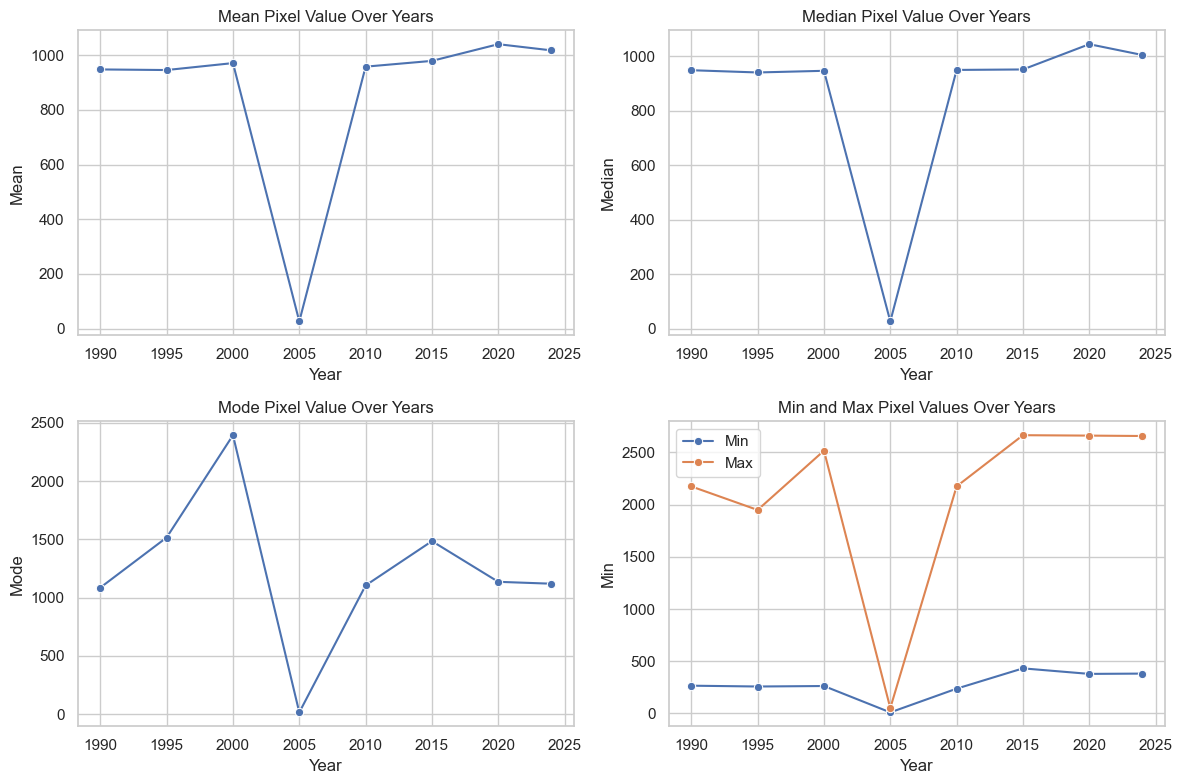

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# Plot Mean, Median, Mode over years
plt.figure(figsize=(12, 8))

# Plot Mean
plt.subplot(2, 2, 1)
sns.lineplot(x='Year', y='Mean', data=stats_df, marker='o')
plt.title('Mean Pixel Value Over Years')

# Plot Median
plt.subplot(2, 2, 2)
sns.lineplot(x='Year', y='Median', data=stats_df, marker='o')
plt.title('Median Pixel Value Over Years')

# Plot Mode
plt.subplot(2, 2, 3)
sns.lineplot(x='Year', y='Mode', data=stats_df, marker='o')
plt.title('Mode Pixel Value Over Years')

# Plot Min and Max
plt.subplot(2, 2, 4)
sns.lineplot(x='Year', y='Min', data=stats_df, marker='o', label='Min')
sns.lineplot(x='Year', y='Max', data=stats_df, marker='o', label='Max')
plt.title('Min and Max Pixel Values Over Years')
plt.legend()

plt.tight_layout()
plt.show()

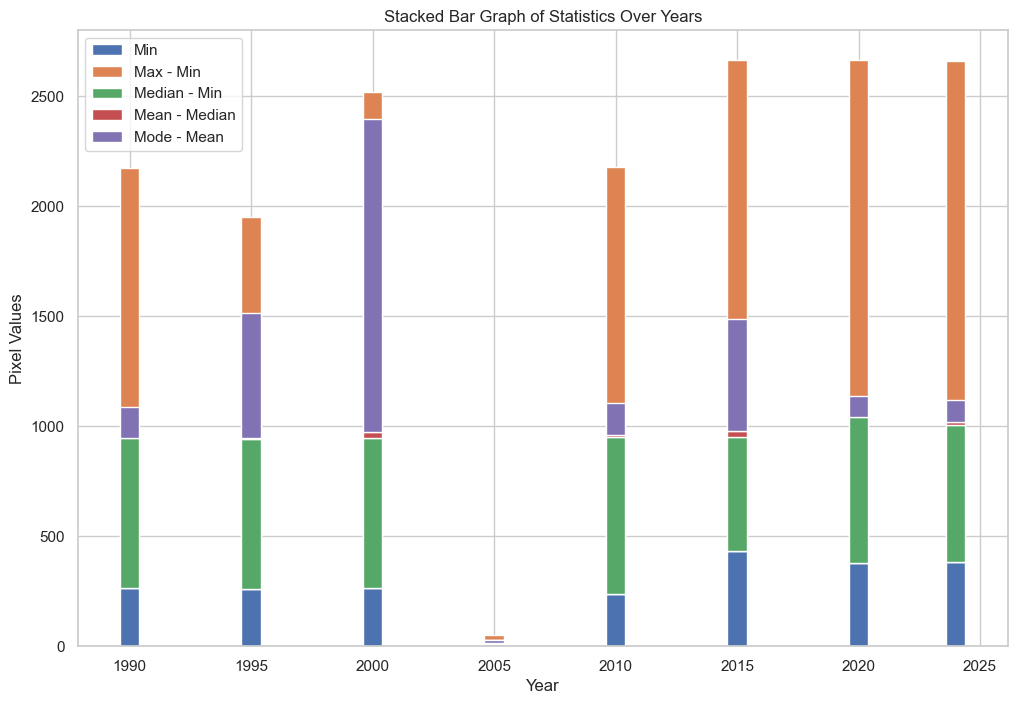

In [16]:
import matplotlib.pyplot as plt

# Prepare data for stacking
stats_df_sorted = stats_df.sort_values('Year')

# Set the figure size
plt.figure(figsize=(12, 8))

# Create a stacked bar plot
plt.bar(stats_df_sorted['Year'], stats_df_sorted['Min'], label='Min')
plt.bar(stats_df_sorted['Year'], stats_df_sorted['Max'] - stats_df_sorted['Min'], bottom=stats_df_sorted['Min'], label='Max - Min')
plt.bar(stats_df_sorted['Year'], stats_df_sorted['Median'] - stats_df_sorted['Min'], bottom=stats_df_sorted['Min'], label='Median - Min')
plt.bar(stats_df_sorted['Year'], stats_df_sorted['Mean'] - stats_df_sorted['Median'], bottom=stats_df_sorted['Median'], label='Mean - Median')
plt.bar(stats_df_sorted['Year'], stats_df_sorted['Mode'] - stats_df_sorted['Mean'], bottom=stats_df_sorted['Mean'], label='Mode - Mean')

# Add labels and title
plt.xlabel('Year')
plt.ylabel('Pixel Values')
plt.title('Stacked Bar Graph of Statistics Over Years')
plt.legend()

plt.show()

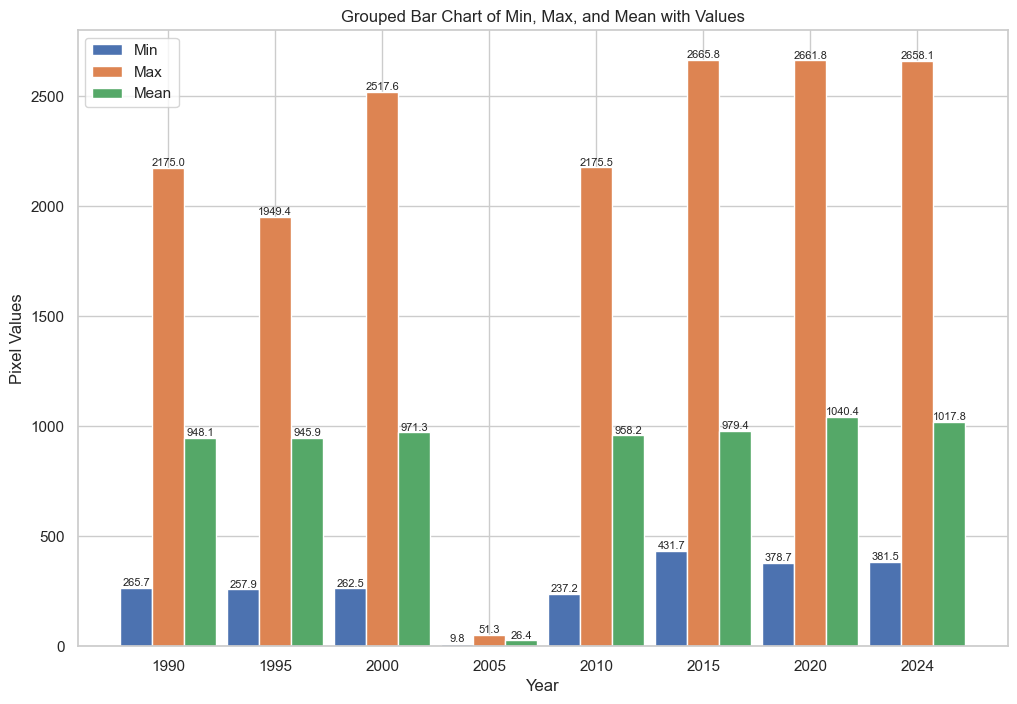

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Sort data by Year
stats_df_sorted = stats_df.sort_values('Year')

years = stats_df_sorted['Year'].values
min_vals = stats_df_sorted['Min'].values
max_vals = stats_df_sorted['Max'].values
mean_vals = stats_df_sorted['Mean'].values

# Increase width of each bar
bar_width = 0.3
x = np.arange(len(years))

# Plot grouped bars
plt.figure(figsize=(12, 8))
plt.bar(x - bar_width, min_vals, width=bar_width, label='Min')
plt.bar(x, max_vals, width=bar_width, label='Max')
plt.bar(x + bar_width, mean_vals, width=bar_width, label='Mean')

# Add labels on top of each bar
for i in range(len(years)):
    plt.text(x[i] - bar_width, min_vals[i], f'{min_vals[i]:.1f}', ha='center', va='bottom', fontsize=8)
    plt.text(x[i], max_vals[i], f'{max_vals[i]:.1f}', ha='center', va='bottom', fontsize=8)
    plt.text(x[i] + bar_width, mean_vals[i], f'{mean_vals[i]:.1f}', ha='center', va='bottom', fontsize=8)

# Set labels and title
plt.xlabel('Year')
plt.ylabel('Pixel Values')
plt.title('Grouped Bar Chart of Min, Max, and Mean with Values')
plt.xticks(x, years)
plt.legend()

plt.show()

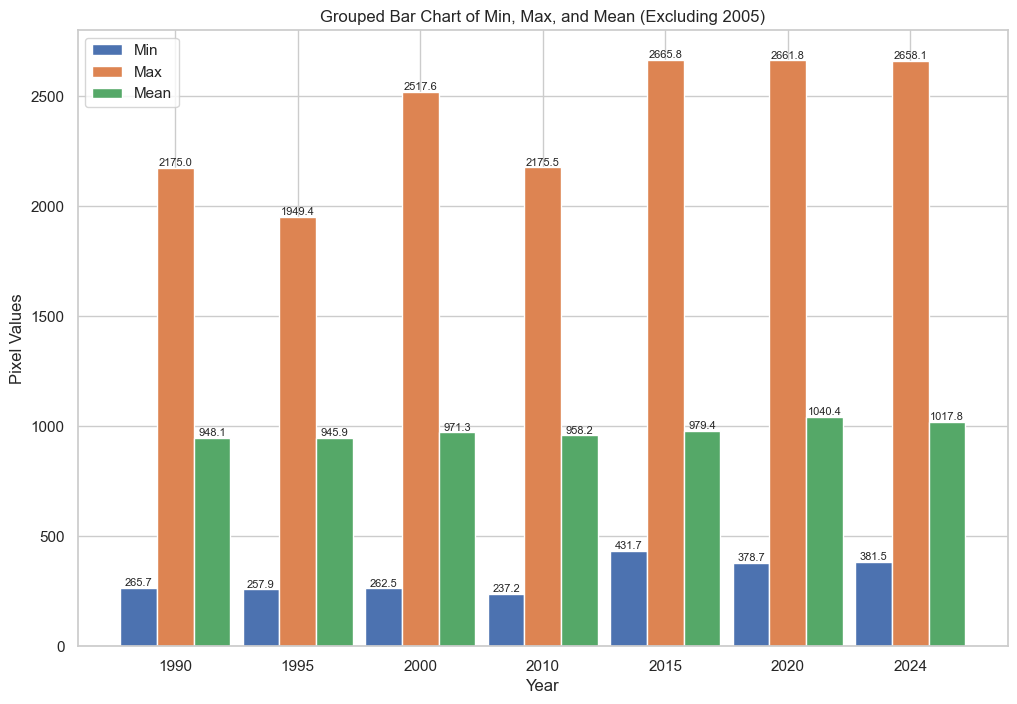

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Filter out the year 2005
stats_df_filtered = stats_df[stats_df['Year'] != 2005].sort_values('Year')

years = stats_df_filtered['Year'].values
min_vals = stats_df_filtered['Min'].values
max_vals = stats_df_filtered['Max'].values
mean_vals = stats_df_filtered['Mean'].values

# Increase width of each bar
bar_width = 0.3
x = np.arange(len(years))

# Plot grouped bars
plt.figure(figsize=(12, 8))
plt.bar(x - bar_width, min_vals, width=bar_width, label='Min')
plt.bar(x, max_vals, width=bar_width, label='Max')
plt.bar(x + bar_width, mean_vals, width=bar_width, label='Mean')

# Add labels on top of each bar
for i in range(len(years)):
    plt.text(x[i] - bar_width, min_vals[i], f'{min_vals[i]:.1f}', ha='center', va='bottom', fontsize=8)
    plt.text(x[i], max_vals[i], f'{max_vals[i]:.1f}', ha='center', va='bottom', fontsize=8)
    plt.text(x[i] + bar_width, mean_vals[i], f'{mean_vals[i]:.1f}', ha='center', va='bottom', fontsize=8)

# Set labels and title
plt.xlabel('Year')
plt.ylabel('Pixel Values')
plt.title('Grouped Bar Chart of Min, Max, and Mean (Excluding 2005)')
plt.xticks(x, years)
plt.legend()
plt.show()

In [22]:
stats_df.to_csv("D:\Sam\Carbon Stock\Remodelling Allometric Biomass\Summaries\Allometric_Biomass.csv", index=False)

In [1]:
import os

folder = r"D:\Sam\Carbon Stock\Remodelling Allometric Biomass\Masked_Rasters"

tif_files = [f for f in os.listdir(folder) if f.lower().endswith(".tif")]

print(f"Number of .tif files found: {len(tif_files)}\n")
for f in tif_files:
    print(f)


Number of .tif files found: 9

AGB_Chave_Mg_ha_1990_UTM35N_clipped.tif
AGB_Chave_Mg_ha_1995_UTM35N_clipped.tif
AGB_Chave_Mg_ha_2000_UTM35N_clipped.tif
AGB_Chave_Mg_ha_2005_UTM35N_clipped.tif
AGB_Chave_Mg_ha_2010_UTM35N_clipped.tif
AGB_Chave_Mg_ha_2015_UTM35N_clipped.tif
AGB_Chave_Mg_ha_2020_UTM35N_clipped.tif
AGB_Chave_Mg_ha_2024_UTM35N_clipped.tif
clipped_raster.tif


In [2]:
import os
import rasterio
import numpy as np

# ------------------------
# Paths
# ------------------------
input_folder = r"D:\Sam\Carbon Stock\Remodelling Allometric Biomass\Masked_Rasters"
output_folder = os.path.join(input_folder, "Carbon_Stock")
os.makedirs(output_folder, exist_ok=True)

carbon_ratio = 0.47  # IPCC standard

# ------------------------
# Process rasters
# ------------------------
for fname in os.listdir(input_folder):
    if not fname.lower().endswith(".tif"):
        continue
    if fname == "clipped_raster.tif":
        continue

    in_path = os.path.join(input_folder, fname)
    out_name = fname.replace("AGB_", "Carbon_").replace("Mg_ha", "MgC_ha")
    out_path = os.path.join(output_folder, out_name)

    with rasterio.open(in_path) as src:
        agb = src.read(1).astype("float32")
        meta = src.meta.copy()
        nodata = src.nodata

        # Handle NoData
        if nodata is not None:
            agb = np.where(agb == nodata, np.nan, agb)

        # Convert to Carbon Stock
        carbon = agb * carbon_ratio

        # Restore NoData
        if nodata is not None:
            carbon = np.where(np.isnan(carbon), nodata, carbon)

        meta.update(dtype="float32")

        with rasterio.open(out_path, "w", **meta) as dst:
            dst.write(carbon.astype("float32"), 1)

    print(f"Carbon stock created: {out_name}")

print("\nAll AGB rasters converted to Carbon Stock (MgC/ha).")


Carbon stock created: Carbon_Chave_MgC_ha_1990_UTM35N_clipped.tif
Carbon stock created: Carbon_Chave_MgC_ha_1995_UTM35N_clipped.tif
Carbon stock created: Carbon_Chave_MgC_ha_2000_UTM35N_clipped.tif
Carbon stock created: Carbon_Chave_MgC_ha_2005_UTM35N_clipped.tif
Carbon stock created: Carbon_Chave_MgC_ha_2010_UTM35N_clipped.tif
Carbon stock created: Carbon_Chave_MgC_ha_2015_UTM35N_clipped.tif
Carbon stock created: Carbon_Chave_MgC_ha_2020_UTM35N_clipped.tif
Carbon stock created: Carbon_Chave_MgC_ha_2024_UTM35N_clipped.tif

All AGB rasters converted to Carbon Stock (MgC/ha).


In [4]:
import rasterio
import numpy as np
import pandas as pd
import glob
import os
from scipy import stats

folder = r"D:\Sam\Carbon Stock\Remodelling Allometric Biomass\Masked_Rasters"
tifs = sorted([f for f in glob.glob(os.path.join(folder, "*.tif"))
               if "clipped_raster" not in f])

results = []

for tif in tifs:
    year = int([y for y in tif.split("_") if y.isdigit()][0])

    with rasterio.open(tif) as src:
        arr = src.read(1)
        arr = arr[arr > 0]  # remove nodata

        # pixel area (ha) — UTM-safe
        pixel_area_ha = abs(src.transform.a * src.transform.e) / 10000

        mean = np.mean(arr)
        median = np.median(arr)
        mode = stats.mode(arr, keepdims=False).mode
        std = np.std(arr)
        minv = np.min(arr)
        maxv = np.max(arr)

        total_carbon = np.sum(arr * pixel_area_ha)

        results.append([
            year, mean, median, mode, minv, maxv, std, total_carbon
        ])

df = pd.DataFrame(results, columns=[
    "Year", "Mean_MgC_ha", "Median_MgC_ha", "Mode_MgC_ha",
    "Min_MgC_ha", "Max_MgC_ha", "Std_MgC_ha", "Total_Carbon_MgC"
])

print(df)


   Year  Mean_MgC_ha  Median_MgC_ha  Mode_MgC_ha  Min_MgC_ha   Max_MgC_ha  \
0  1990   948.064697     949.208984  1086.415527  265.679260  2174.965332   
1  1995   945.875305     940.954590  1516.458374  257.882294  1949.392212   
2  2000   971.272705     947.061218  2394.457275  262.462677  2517.571777   
3  2005    26.408979      26.355526    15.825771    9.834850    51.271648   
4  2010   958.248718     950.274597  1105.305908  237.249863  2175.482666   
5  2015   979.366882     951.990601  1485.369995  431.670135  2665.772461   
6  2020  1040.419067    1044.828003  1136.243286  378.668854  2661.814697   
7  2024  1017.812500    1005.123474  1120.053589  381.495087  2658.056396   

   Std_MgC_ha  Total_Carbon_MgC  
0  256.913055      1.870256e+06  
1  240.865540      1.865936e+06  
2  270.742737      1.916037e+06  
3    6.566746      5.214662e+04  
4  245.595917      1.890346e+06  
5  234.768677      1.933548e+06  
6  295.095032      2.054082e+06  
7  272.172974      2.009450e+06  


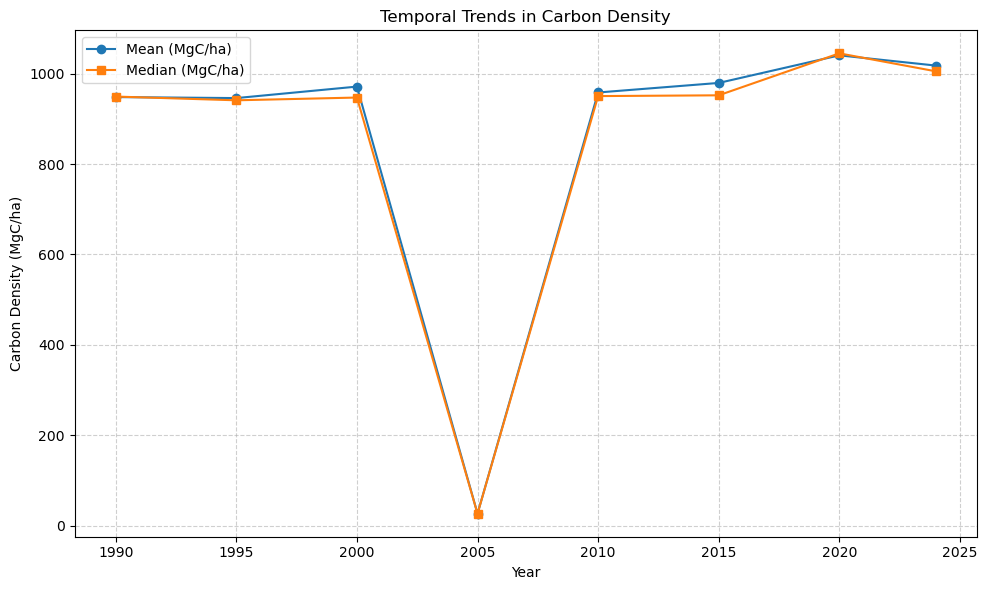

In [5]:
import matplotlib.pyplot as plt

# Convert Total Carbon to TgC for readability
df["Total_Carbon_TgC"] = df["Total_Carbon_MgC"] / 1e6

plt.figure(figsize=(10,6))
plt.plot(df["Year"], df["Mean_MgC_ha"], marker='o', label="Mean (MgC/ha)")
plt.plot(df["Year"], df["Median_MgC_ha"], marker='s', label="Median (MgC/ha)")
plt.xlabel("Year")
plt.ylabel("Carbon Density (MgC/ha)")
plt.title("Temporal Trends in Carbon Density")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


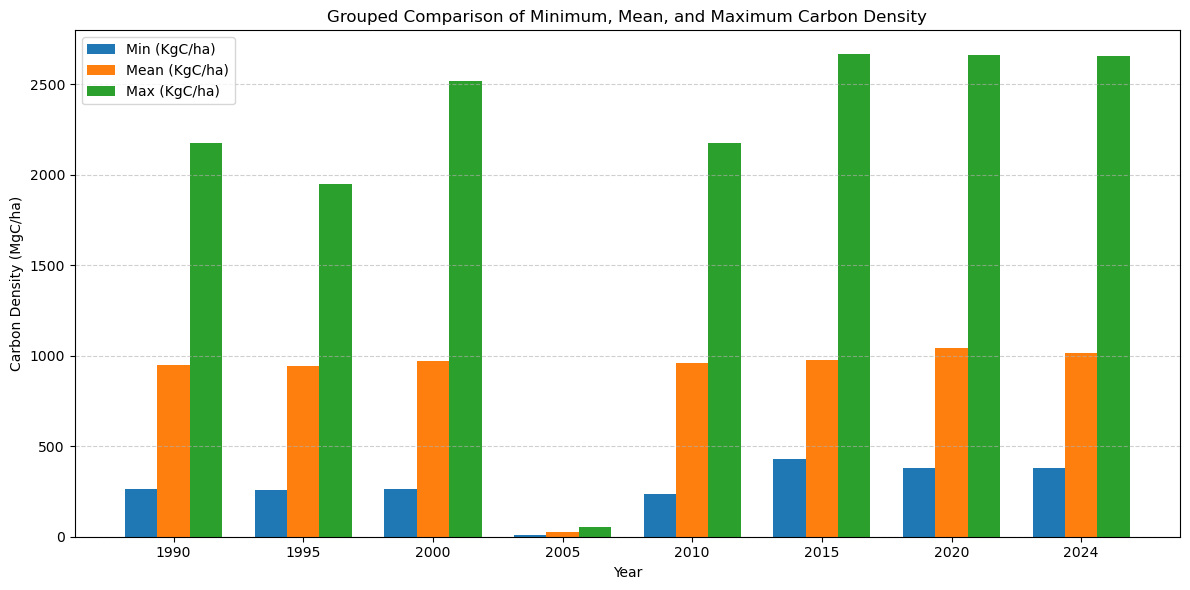

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Data
years = df["Year"].astype(str)
min_vals = df["Min_MgC_ha"]
mean_vals = df["Mean_MgC_ha"]
max_vals = df["Max_MgC_ha"]

x = np.arange(len(years))
width = 0.25

plt.figure(figsize=(12,6))

plt.bar(x - width, min_vals, width, label="Min (KgC/ha)")
plt.bar(x, mean_vals, width, label="Mean (KgC/ha)")
plt.bar(x + width, max_vals, width, label="Max (KgC/ha)")

plt.xlabel("Year")
plt.ylabel("Carbon Density (MgC/ha)")
plt.title("Grouped Comparison of Minimum, Mean, and Maximum Carbon Density")
plt.xticks(x, years)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


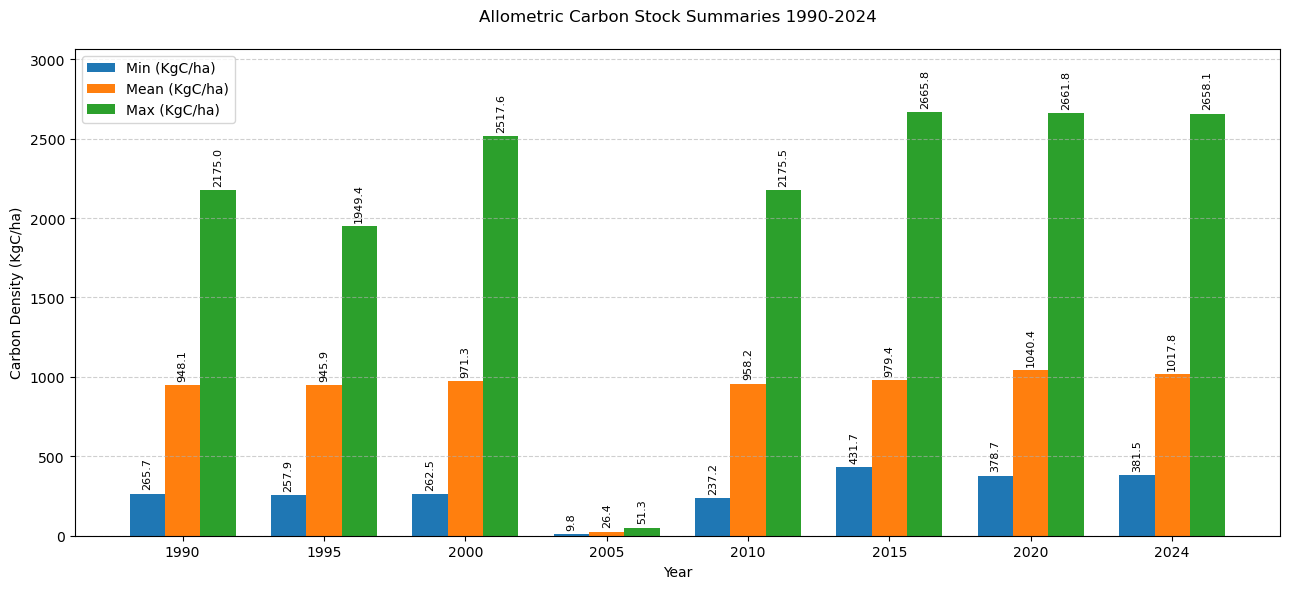

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Data
years = df["Year"].astype(str)
min_vals = df["Min_MgC_ha"]
mean_vals = df["Mean_MgC_ha"]
max_vals = df["Max_MgC_ha"]

x = np.arange(len(years))
width = 0.25

plt.figure(figsize=(13,6))

bars_min = plt.bar(x - width, min_vals, width, label="Min (KgC/ha)")
bars_mean = plt.bar(x, mean_vals, width, label="Mean (KgC/ha)")
bars_max = plt.bar(x + width, max_vals, width, label="Max (KgC/ha)")

plt.xlabel("Year")
plt.ylabel("Carbon Density (KgC/ha)")
plt.title("Allometric Carbon Stock Summaries 1990-2024", pad=20)
plt.xticks(x, years)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)

# -------------------------
# Add headroom on y-axis
# -------------------------
y_max = max(max_vals)
plt.ylim(0, y_max * 1.15)  # 15% headroom

# -------------------------
# Add value labels
# -------------------------
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + y_max * 0.01,  # slight offset above bar
            f"{height:.1f}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90
        )

add_labels(bars_min)
add_labels(bars_mean)
add_labels(bars_max)

plt.tight_layout()
plt.show()


In [3]:
import geopandas as gpd
shp_path = r"D:\Sam\Carbon Stock\Remodelling Allometric Biomass\Carbon Stock\Simulated LULC\Ensemble_LULC_2035.shp"
gdf_lulc_2035 = gpd.read_file(shp_path)


In [4]:
gdf_lulc_2035.head()

,Id,gridcode,Shape_Leng,Shape_Area,area_ha,geometry
0,1,3,0.000549,1.543999e-08,0.019001,"POLYGON ((35.16222 1.29074, 35.16237 1.29067, ..."
1,2,3,0.001069,7.009152e-08,0.086255,"POLYGON ((35.16276 1.29038, 35.16286 1.29036, ..."
2,3,3,0.002271,2.225574e-07,0.273880,"POLYGON ((35.22887 1.28976, 35.22902 1.28964, ..."
3,4,3,0.000818,3.754422e-08,0.046202,"POLYGON ((35.16464 1.28922, 35.16476 1.28915, ..."
4,5,1,0.000313,5.358787e-09,0.006595,"POLYGON ((35.16487 1.28899, 35.16487 1.28908, ..."


In [5]:
agb_constants = {
    1: 436.68,  # Planted dense forest
    2: 113.54,  # Moderately dense
    3: 138.22   # Open class
}

In [6]:
gdf_lulc_2035["agb_ton_per_ha"] = gdf_lulc_2035["gridcode"].map(agb_constants)

In [7]:
gdf_lulc_2035["AGB_tons"] = (
    gdf_lulc_2035["area_ha"] * gdf_lulc_2035["agb_ton_per_ha"]
)


In [8]:
gdf_lulc_2035[["gridcode", "area_ha", "agb_ton_per_ha", "AGB_tons"]].head()
gdf_lulc_2035[gdf_lulc_2035["agb_ton_per_ha"].isna()]["gridcode"].unique()
total_agb = gdf_lulc_2035["AGB_tons"].sum()
total_agb

470878.57974003657

In [9]:
# AGB constants (tons per hectare)
agb_constants = {
    1: 436.68,  # Dense planted forest
    2: 113.54,  # Moderately dense forest
    3: 138.22   # Open forest
}

# Append AGB column
gdf_lulc_2035["AGB_tons"] = (
    gdf_lulc_2035["area_ha"] *
    gdf_lulc_2035["gridcode"].map(agb_constants)
)


In [10]:
gdf_lulc_2035.head()

,Id,gridcode,Shape_Leng,Shape_Area,area_ha,geometry,agb_ton_per_ha,AGB_tons
0,1,3,0.000549,1.543999e-08,0.019001,"POLYGON ((35.16222 1.29074, 35.16237 1.29067, ...",138.22,2.626249
1,2,3,0.001069,7.009152e-08,0.086255,"POLYGON ((35.16276 1.29038, 35.16286 1.29036, ...",138.22,11.922152
2,3,3,0.002271,2.225574e-07,0.273880,"POLYGON ((35.22887 1.28976, 35.22902 1.28964, ...",138.22,37.855694
3,4,3,0.000818,3.754422e-08,0.046202,"POLYGON ((35.16464 1.28922, 35.16476 1.28915, ...",138.22,6.386054
4,5,1,0.000313,5.358787e-09,0.006595,"POLYGON ((35.16487 1.28899, 35.16487 1.28908, ...",436.68,2.879708


In [11]:
# Carbon fraction
carbon_fraction = 0.47

# Append Carbon Stock column
gdf_lulc_2035["Carbon_tons"] = gdf_lulc_2035["AGB_tons"] * carbon_fraction


In [12]:
gdf_lulc_2035[["gridcode", "AGB_tons", "Carbon_tons"]].head()
total_agb = gdf_lulc_2035["AGB_tons"].sum()
total_carbon = gdf_lulc_2035["Carbon_tons"].sum()

total_agb, total_carbon


(470878.57974003657, 221312.93247781717)

In [14]:
gdf_lulc_2035.head(10)

,Id,gridcode,Shape_Leng,Shape_Area,area_ha,geometry,agb_ton_per_ha,AGB_tons,Carbon_tons
0,1,3,0.000549,1.543999e-08,0.019001,"POLYGON ((35.16222 1.29074, 35.16237 1.29067, ...",138.22,2.626249,1.234337
1,2,3,0.001069,7.009152e-08,0.086255,"POLYGON ((35.16276 1.29038, 35.16286 1.29036, ...",138.22,11.922152,5.603412
2,3,3,0.002271,2.225574e-07,0.273880,"POLYGON ((35.22887 1.28976, 35.22902 1.28964, ...",138.22,37.855694,17.792176
3,4,3,0.000818,3.754422e-08,0.046202,"POLYGON ((35.16464 1.28922, 35.16476 1.28915, ...",138.22,6.386054,3.001446
4,5,1,0.000313,5.358787e-09,0.006595,"POLYGON ((35.16487 1.28899, 35.16487 1.28908, ...",436.68,2.879708,1.353463
5,6,3,0.000618,1.909494e-08,0.023498,"POLYGON ((35.23008 1.28863, 35.23019 1.28856, ...",138.22,3.247935,1.526529
6,7,3,0.002156,2.178820e-07,0.268127,"POLYGON ((35.22954 1.28841, 35.22874 1.28841, ...",138.22,37.060514,17.418442
7,8,2,0.000566,1.326771e-08,0.016327,"POLYGON ((35.22703 1.28814, 35.22708 1.28834, ...",113.54,1.853802,0.871287
8,9,3,0.001078,7.262733e-08,0.089375,"POLYGON ((35.22712 1.28814, 35.22712 1.28836, ...",138.22,12.353482,5.806136
9,10,3,0.000824,3.779143e-08,0.046506,"POLYGON ((35.22694 1.28787, 35.22698 1.28801, ...",138.22,6.428101,3.021207


In [15]:
agb_min = gdf_lulc_2035["AGB_tons"].min()
agb_max = gdf_lulc_2035["AGB_tons"].max()

carbon_min = gdf_lulc_2035["Carbon_tons"].min()
carbon_max = gdf_lulc_2035["Carbon_tons"].max()

agb_min, agb_max, carbon_min, carbon_max


(0.28188235180000004, 204377.157, 0.13248470534600001, 96057.26379)

In [16]:
# Define output path
shapefile_path = r"D:\Sam\Carbon Stock\Remodelling Allometric Biomass\gdf_2035.shp"
# Export GeoDataFrame to Shapefile
gdf_lulc_2035.to_file(shapefile_path, driver='ESRI Shapefile')
print(f"Shapefile exported successfully to: {shapefile_path}")

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16232\3728193570.py:4: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_lulc_2035.to_file(shapefile_path, driver='ESRI Shapefile')


Shapefile exported successfully to: D:\Sam\Carbon Stock\Remodelling Allometric Biomass\gdf_2035.shp


C:\Users\Administrator\miniconda3\envs\geo_env\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'agb_ton_per_ha' to 'agb_ton_pe'
  ogr_write(
C:\Users\Administrator\miniconda3\envs\geo_env\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Carbon_tons' to 'Carbon_ton'
  ogr_write(
